PROBLEM 3 - "Does the institution's AI policy actually influence student outcomes — and is it working?"

In [2]:
import pandas as pd

df = pd.read_csv('ai_student_impact_dataset.csv')
df.head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


STEP 0 - Clean the data

In [2]:
columns = ['Institutional_Policy', 'Skill_Retention_Score', 
                'Burnout_Risk_Level', 'Pre_Semester_GPA', 
                'Post_Semester_GPA']
            
df[columns].isnull().sum()

Institutional_Policy     0
Skill_Retention_Score    0
Burnout_Risk_Level       0
Pre_Semester_GPA         0
Post_Semester_GPA        0
dtype: int64

Step 1 → Check what policy categories exist + distribution

In [3]:
df['Institutional_Policy'].value_counts(normalize = True).round(3)*100

Institutional_Policy
Allowed_With_Citation    50.4
Actively_Encouraged      30.0
Strict_Ban               19.6
Name: proportion, dtype: float64

Step 2 → Compare GPA change and Skill Retention across policies (ANOVA)

In [4]:
df['GPA_Change'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']

df.head(10)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level,GPA_Change
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High,-0.025
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low,-0.125
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium,0.101
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium,0.211
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium,0.163
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High,0.217
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium,0.378
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium,0.219
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium,-0.024
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High,-0.068


In [5]:
from scipy import stats

f_stat, p_value = stats.f_oneway(
    df[df['Institutional_Policy'] == 'Allowed_With_Citation']['GPA_Change'],
    df[df['Institutional_Policy'] == 'Actively_Encouraged']['GPA_Change'],
    df[df['Institutional_Policy'] == 'Strict_Ban']['GPA_Change']
)

print("F-Statistic:", round(f_stat,3))
print("P-Value:", round(p_value,6))

F-Statistic: 46.294
P-Value: 0.0


In [6]:
f2, p2 = stats.f_oneway(
    df[df['Institutional_Policy'] == 'Allowed_With_Citation']['Skill_Retention_Score'],
    df[df['Institutional_Policy'] == 'Actively_Encouraged']['Skill_Retention_Score'],
    df[df['Institutional_Policy'] == 'Strict_Ban']['Skill_Retention_Score']
)

print("F-Statistic:", round(f2,3))
print("P-Value:", round(p2,6))

F-Statistic: 23.579
P-Value: 0.0


Step 2b → Tukey's Post-Hoc (which specific policies differ?)

In [7]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_usecase = pairwise_tukeyhsd(
    endog = df['GPA_Change'],
    groups = df['Institutional_Policy'],
    alpha = 0.05
)

print(tukey_usecase)

               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------
  Actively_Encouraged Allowed_With_Citation   0.0023 0.4511 -0.0022  0.0068  False
  Actively_Encouraged            Strict_Ban  -0.0187    0.0 -0.0244  -0.013   True
Allowed_With_Citation            Strict_Ban   -0.021    0.0 -0.0262 -0.0158   True
----------------------------------------------------------------------------------


In [8]:
tukey_retention = pairwise_tukeyhsd(
    endog = df['Skill_Retention_Score'],
    groups = df['Institutional_Policy'],
    alpha = 0.05
)

print(tukey_retention)

               Multiple Comparison of Means - Tukey HSD, FWER=0.05                
        group1                group2        meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------
  Actively_Encouraged Allowed_With_Citation  -0.2185 0.2473 -0.5394  0.1024  False
  Actively_Encouraged            Strict_Ban  -1.1365    0.0 -1.5408 -0.7321   True
Allowed_With_Citation            Strict_Ban  -0.9179    0.0 -1.2885 -0.5474   True
----------------------------------------------------------------------------------


Step 3 → Compare Burnout Risk Level across policies (chi-square test)

In [9]:
from scipy.stats import chi2_contingency 

contingency_table = pd.crosstab(
    df['Institutional_Policy'],
    df['Burnout_Risk_Level']
)

print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-Square Statistic: {round(chi2, 3)}")
print(f"P-Value: {round(p, 6)}")
print(f"Degrees of Freedom: {dof}")

Burnout_Risk_Level     High   Low  Medium
Institutional_Policy                     
Actively_Encouraged    3563  5079    6346
Allowed_With_Citation  6011  8320   10893
Strict_Ban             2913  2970    3905

Chi-Square Statistic: 153.397
P-Value: 0.0
Degrees of Freedom: 4


Before Visualizations — One Quick Addition
Let's calculate the proportions per policy so we can compare fairly (since group sizes differ)

In [10]:
burnout_pct = contingency_table.div(
    contingency_table.sum(axis=1), axis=0
) * 100

print(round(burnout_pct, 1))

Burnout_Risk_Level     High   Low  Medium
Institutional_Policy                     
Actively_Encouraged    23.8  33.9    42.3
Allowed_With_Citation  23.8  33.0    43.2
Strict_Ban             29.8  30.3    39.9


Step 4 - Visualize the findings and write conclusions

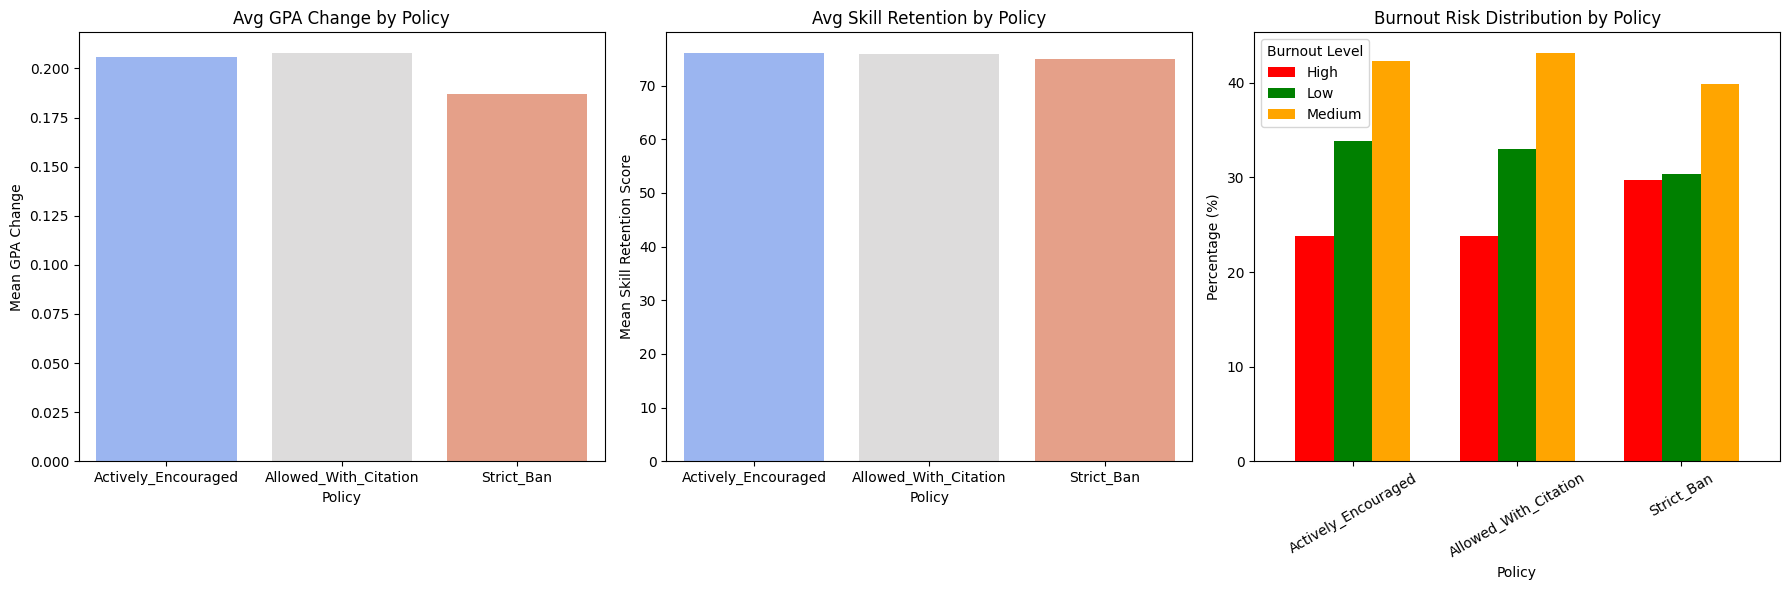

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,6))

policy_gpa = df.groupby('Institutional_Policy')['GPA_Change'].mean().reset_index()
sns.barplot(data=policy_gpa, x='Institutional_Policy', y='GPA_Change', hue='Institutional_Policy', ax=axes[0], palette='coolwarm', legend=False)
axes[0].set_title('Avg GPA Change by Policy')
axes[0].set_xlabel('Policy')
axes[0].set_ylabel('Mean GPA Change')


policy_skill = df.groupby('Institutional_Policy')['Skill_Retention_Score'].mean().reset_index()
sns.barplot(data=policy_skill, x='Institutional_Policy', y='Skill_Retention_Score', hue='Institutional_Policy', ax=axes[1], palette='coolwarm', legend=False)
axes[1].set_title('Avg Skill Retention by Policy')
axes[1].set_xlabel('Policy')
axes[1].set_ylabel('Mean Skill Retention Score')


burnout_pct.plot(kind='bar', ax=axes[2], color=['red', 'green', 'orange'], width=0.7)
axes[2].set_title('Burnout Risk Distribution by Policy')
axes[2].set_xlabel('Policy')
axes[2].set_ylabel('Percentage (%)')
axes[2].legend(title='Burnout Level')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [12]:
df.groupby('Institutional_Policy')['Skill_Retention_Score'].mean().round(3)

Institutional_Policy
Actively_Encouraged      76.131
Allowed_With_Citation    75.912
Strict_Ban               74.994
Name: Skill_Retention_Score, dtype: float64

## Problem 3 — Final Conclusions

### Does institutional AI policy influence student outcomes?
Yes. ANOVA confirmed statistically significant differences across all three 
outcome measures — GPA Change, Skill Retention Score, and Burnout Risk Level.

### Which policy performs best?
Actively_Encouraged and Allowed_With_Citation perform nearly identically 
across all metrics. There is no statistically significant difference between 
them — meaning requiring citation does not hurt outcomes compared to 
freely encouraging AI.

### Which policy performs worst?
Strict_Ban consistently produces the worst outcomes:
- Lowest average GPA change
- Lowest average Skill Retention Score (~1 point below others)
- Highest proportion of High burnout students (29.8% vs 23.8%)
- Lowest proportion of Low burnout students (30.3% vs ~34%)

### Is the Strict_Ban policy working as intended?
No. Banning AI does not protect students — it disadvantages them. 
Students under Strict_Ban show worse academic performance, lower skill 
retention, and higher burnout rates compared to students whose institutions 
allow or encourage AI use.

### Caveat
The Skill Retention difference is statistically significant but practically 
small (only ~1 point gap). The burnout and GPA findings are stronger 
evidence against Strict_Ban.